In [10]:
from datasets import load_dataset
from datasets import Audio
from IPython.display import Audio as IPythonAudio

minds = load_dataset("PolyAI/minds14", "en-US", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16000))

minds[0]

Using the latest cached version of the dataset since PolyAI/minds14 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'en-US' at /home/nitin/.cache/huggingface/datasets/PolyAI___minds14/en-US/1.0.0/7bdf27fccad4efc6da7c00f739d96bfa0d25a7a85f2244755a73c865f70182bc (last modified on Tue Jul 29 11:43:47 2025).


{'path': '/home/nitin/.cache/huggingface/datasets/downloads/extracted/587962313ce21a6a8111a65727f66266aa27e7ff07ccaed1fb76aef0c8e25fb1/en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ff6dc9a86b0>,
 'transcription': 'I would like to set up a joint account with my partner',
 'english_transcription': 'I would like to set up a joint account with my partner',
 'intent_class': 11,
 'lang_id': 4}

In [2]:
from transformers import pipeline

classifier = pipeline("audio-classification", model="anton-l/xtreme_s_xlsr_300m_minds14")
example = minds[0]
predictions = classifier(example["audio"]["array"])
print(predictions)

# Get prediction with highest confidence score
max_prediction = max(predictions, key=lambda x: x['score'])
print(f"\nMost likely intent: {max_prediction['label']} with score: {max_prediction['score']:.4f}")


/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at anton-l/xtreme_s_xlsr_300m_minds14 were not used when initializing Wav2Vec2ForSequenceClassification: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model 

[{'score': 0.9984103441238403, 'label': 'joint_account'}, {'score': 0.00044178011012263596, 'label': 'business_loan'}, {'score': 0.0004378957091830671, 'label': 'cash_deposit'}, {'score': 0.0001265271130250767, 'label': 'atm_limit'}, {'score': 0.00010100915096700191, 'label': 'balance'}]

Most likely intent: joint_account with score: 0.9984


In [3]:
from transformers import pipeline

pipe = pipeline("text-to-speech", model="suno/bark-small")
text = "Ladybugs have had important roles in culture and religion, being associated with luck, love, fertility and prophecy. "
output = pipe(text)


/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/transformers/models/encodec/modeling_encodec.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("padding_total", torch.tensor(kernel_size - stride, dtype=torch.int64), persistent=False)
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [11]:
print(output)
aud = output['audio']
print(aud, aud.shape)
IPythonAudio(output["audio"], rate=output["sampling_rate"])

{'audio': array([[0.07891291, 0.08223306, 0.0868123 , ..., 0.00022836, 0.00022922,
        0.00022601]], shape=(1, 172480), dtype=float32), 'sampling_rate': 24000}
[[0.07891291 0.08223306 0.0868123  ... 0.00022836 0.00022922 0.00022601]] (1, 172480)


In [ ]:
fr_text = "Contrairement à une idée répandue, le nombre de points sur les élytres d'une coccinelle ne correspond pas à son âge, ni en nombre d'années, ni en nombre de mois. "
output = pipe(fr_text)
IPythonAudio(output["audio"], rate=output["sampling_rate"])

In [12]:
song = "♪ In the jungle, the mighty jungle, the ladybug was seen. ♪ "
output = pipe(song)
IPythonAudio(output["audio"], rate=output["sampling_rate"])

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [16]:
from datasets import load_dataset

# Load VoxPopuli dataset in streaming mode
# Option 2: Use LibriSpeech
dataset = load_dataset("librispeech_asr", "clean", split="train.100", streaming=True)

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

In [30]:
import librosa

# Skip first 2 examples and get the 3rd one
example = next(iter(dataset.skip(2).take(1)))
print(example['audio'])
IPythonAudio(example['audio']['array'], rate=example['audio']['sampling_rate'])


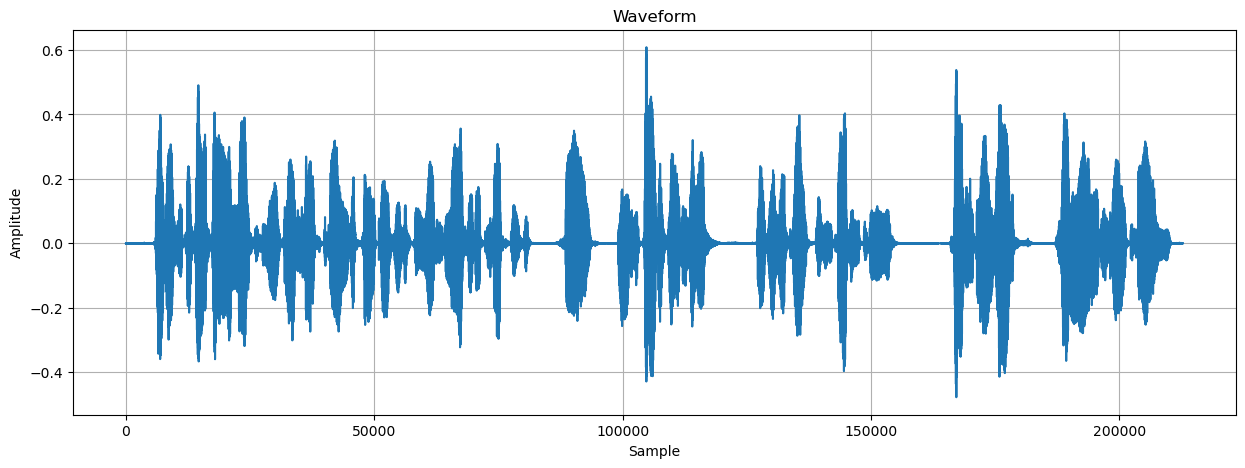

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(example['audio']['array'])
plt.title('Waveform')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


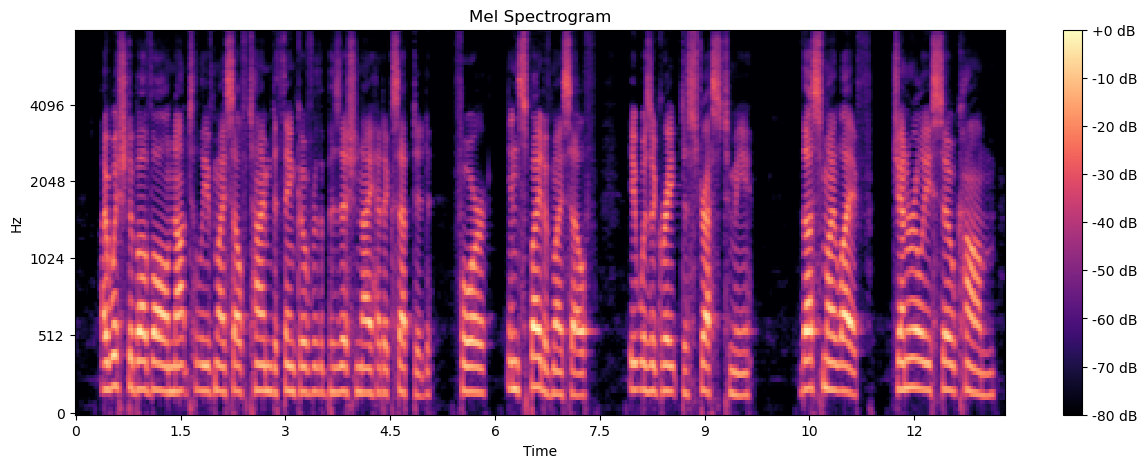

In [27]:
import librosa.display
import numpy as np

# Calculate mel spectrogram
mel_spect = librosa.feature.melspectrogram(y=example['audio']['array'], 
                                          sr=example['audio']['sampling_rate'])

# Convert to log scale
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

plt.figure(figsize=(15, 5))
librosa.display.specshow(mel_spect_db, 
                        sr=example['audio']['sampling_rate'],
                        x_axis='time',
                        y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()


In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset

# load model and processor
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")
model.config.forced_decoder_ids = None

/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [35]:
sample = example['audio']
input_features = processor(sample["array"], sampling_rate=sample["sampling_rate"], return_tensors="pt").input_features 

# generate token ids
predicted_ids = model.generate(input_features)
print(predicted_ids)

# decode token ids to text
print(f"Original text: {example['text']}")
processor.batch_decode(predicted_ids, skip_special_tokens=True, language='en')

tensor([[50258, 50259, 50359, 50363,   286,  3172,   281,  3673,   439,   406,
           281,  1856,  2059,   565,   281,   519,   670,   264,  2535,   286,
           632,  9035,   337,    11,   294, 22794,   295,  2059,    11,   309,
           390,   257,   869, 24516,   281,   385,    13, 13827,   452,   993,
            11,  5101,   370,  7151,    11, 50257]])
Original text: I WISHED ABOVE ALL NOT TO LEAVE MYSELF TIME TO THINK OVER THE POSITION I HAD ACCEPTED FOR IN SPITE OF MYSELF IT WAS A GREAT DISTRESS TO ME THUS MY LIFE GENERALLY SO CALM


[' I wish to above all not to leave myself time to think over the position I had accepted for, in spite of myself, it was a great distress to me. Thus my life, generally so calm,']